In [67]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

In [68]:
# reading with csv file
movies =pd.read_csv('movies_updated.csv')

In [69]:
movies.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 15 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   name       4000 non-null   object 
 1   rating     3960 non-null   object 
 2   genre      4000 non-null   object 
 3   year       4000 non-null   int64  
 4   released   4000 non-null   object 
 5   score      4000 non-null   float64
 6   votes      4000 non-null   int64  
 7   director   4000 non-null   object 
 8   writer     3999 non-null   object 
 9   star       3999 non-null   object 
 10  country    4000 non-null   object 
 11  budget     4000 non-null   int64  
 12  gross      3831 non-null   float64
 13  company    3990 non-null   object 
 14  runtime,,  4000 non-null   object 
dtypes: float64(2), int64(3), object(10)
memory usage: 468.9+ KB


In [ ]:
Exercise 1

In [113]:
#1. Create a new feature called ROI: ROI = (gross - budget) / budget
roiTable = movies[["name" , "gross" , "budget","votes" , "score","genre","company","director","country","year"]].copy()
print(roiTable.count())

#2. Remove movies with missing values in budget , gross , or score .
# replacing missing values in budget , gross , or score .
print("--- replacing the missing values from each column ---")
roiTable['budget'] = roiTable['budget'].astype(float)
roiTable.loc[:, 'budget'] = np.where(roiTable['budget'] == 0, np.nan, roiTable['budget'])
roiTable.loc[:, "score"] = np.where(roiTable["score"] == 0, np.nan, roiTable["score"])
print(roiTable)

name        4000
gross       3831
budget      4000
votes       4000
score       4000
genre       4000
company     3990
director    4000
country     4000
year        4000
dtype: int64
--- replacing the missing values from each column ---
                                                name        gross      budget  \
0                                        The Shining   46998772.0  19000000.0   
1                                    The Blue Lagoon   58853106.0   4500000.0   
2     Star Wars: Episode V - The Empire Strikes Back  538375067.0  18000000.0   
3                                          Airplane!   83453539.0   3500000.0   
4                                         Caddyshack   39846344.0   6000000.0   
...                                              ...          ...         ...   
3995                                   Birthday Girl   16171098.0  13000000.0   
3996                                    Human Nature    1574660.0         NaN   
3997                              

In [114]:
print("--- Couting befor and after removing the missing values from each column ---")
print(roiTable.isnull().sum())
roiTable = roiTable.dropna() 
print(roiTable.isnull().sum())

--- Couting befor and after removing the missing values from each column ---
name           0
gross        169
budget      1392
votes          0
score          0
genre          0
company       10
director       0
country        0
year           0
dtype: int64
name        0
gross       0
budget      0
votes       0
score       0
genre       0
company     0
director    0
country     0
year        0
dtype: int64


In [115]:
# creating new ROI column 
roiTable["ROI"] = (roiTable["gross"] - roiTable["budget"]) / roiTable["budget"]
roiTable

,name,gross,budget,votes,score,genre,company,director,country,year,ROI
0,The Shining,46998772.0,19000000.0,927000,8.4,Drama,Warner Bros.,Stanley Kubrick,United Kingdom,1980,1.473620
1,The Blue Lagoon,58853106.0,4500000.0,65000,5.8,Adventure,Columbia Pictures,Randal Kleiser,United States,1980,12.078468
2,Star Wars: Episode V - The Empire Strikes Back,538375067.0,18000000.0,1200000,8.7,Action,Lucasfilm,Irvin Kershner,United States,1980,28.909726
3,Airplane!,83453539.0,3500000.0,221000,7.7,Comedy,Paramount Pictures,Jim Abrahams,United States,1980,22.843868
4,Caddyshack,39846344.0,6000000.0,108000,7.3,Comedy,Orion Pictures,Harold Ramis,United States,1980,5.641057
...,...,...,...,...,...,...,...,...,...,...,...
3994,O,19260537.0,5000000.0,19000,6.1,Drama,Chickie the Cop,Tim Blake Nelson,United States,2001,2.852107
3995,Birthday Girl,16171098.0,13000000.0,25000,6.1,Comedy,FilmFour,Jez Butterworth,United Kingdom,2001,0.243931
3997,Made,5480653.0,5000000.0,18000,6.4,Comedy,Artisan Entertainment,Jon Favreau,United States,2001,0.096131
3998,One Night at McCool's,13578186.0,18000000.0,29000,6.1,Comedy,October Films,Harald Zwart,United States,2001,-0.245656


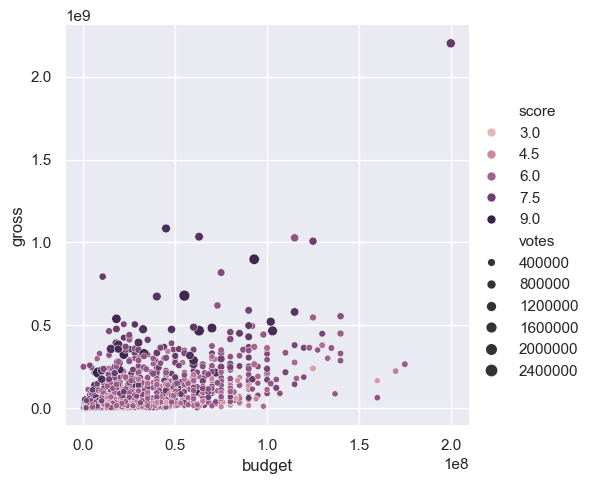

In [116]:
#3. Create a scatter plot that simultaneously shows:
sns.set_theme()
sns.relplot(data=roiTable, x="budget", y="gross", hue="score", size="votes")


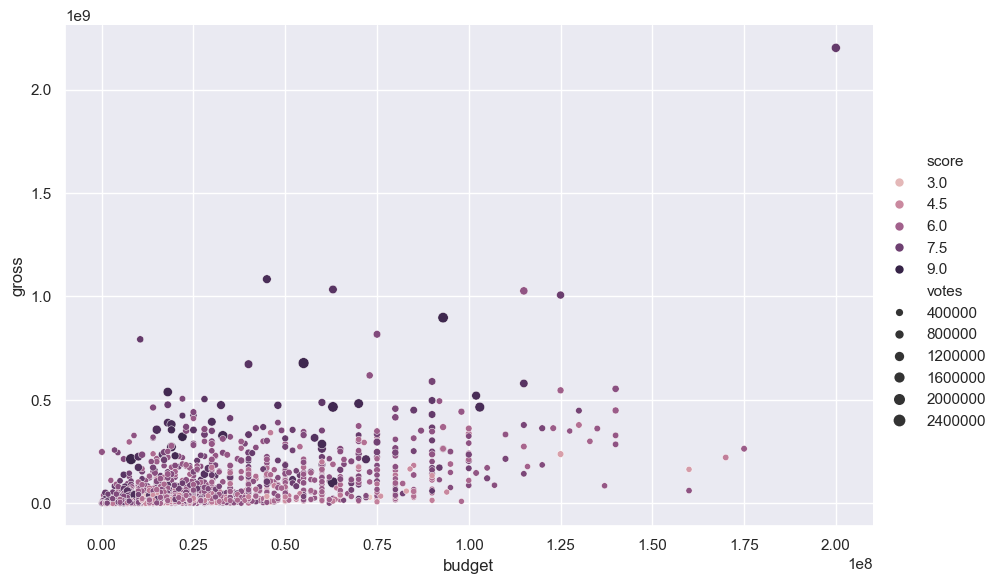

In [117]:
# 4 increased the box size for more readability
sns.set_theme()
sns.relplot(
    data=roiTable,
    x="budget",
    y="gross",
    hue="score",
    size="votes",
    height=6,      
    aspect=1.5    
)


In [125]:
#5. Identify and annotate the 10 movies with the highest ROI.
topTenROI= roiTable.nlargest(10, "ROI")
topTenROI

,name,gross,budget,votes,score,genre,company,director,country,year,ROI
3459,The Blair Witch Project,248639099.0,60000.0,239000,6.5,Horror,Haxan Films,Daniel Myrick,United States,1999,4142.984983
2093,El Mariachi,2040920.0,7000.0,64000,6.9,Action,Columbia Pictures,Robert Rodriguez,Mexico,1992,290.560000
2467,Clerks,3151130.0,27000.0,214000,7.7,Comedy,View Askew Productions,Kevin Smith,United States,1994,115.708519
3233,In the Company of Men,2804473.0,25000.0,13000,7.2,Comedy,Alliance Atlantis Communications,Neil LaBute,Canada,1997,111.178920
209,E.T. the Extra-Terrestrial,792910554.0,10500000.0,381000,7.8,Family,Universal Pictures,Steven Spielberg,United States,1982,74.515291
3089,The Full Monty,257938649.0,3500000.0,101000,7.2,Comedy,Redwave Films,Peter Cattaneo,United Kingdom,1997,72.696757
5,Friday the 13th,39754601.0,550000.0,123000,6.4,Horror,Paramount Pictures,Sean S. Cunningham,United States,1980,71.281093
2458,Four Weddings and a Funeral,245700832.0,4400000.0,144000,7.1,Comedy,PolyGram Filmed Entertainment,Mike Newell,United Kingdom,1994,54.841098
3291,Pi,3221152.0,60000.0,173000,7.4,Drama,Harvest Filmworks,Darren Aronofsky,United States,1998,52.685867
1684,Slacker,1228108.0,23000.0,20000,7.1,Comedy,Detour Filmproduction,Richard Linklater,United States,1990,52.396000


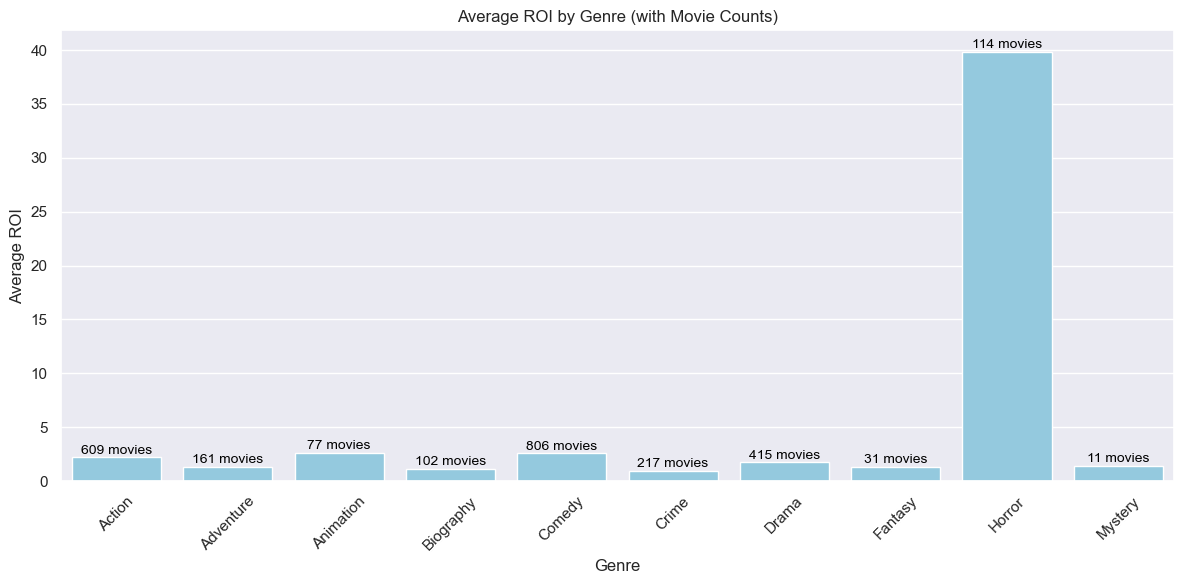

In [127]:
#6. Creating a second visualization that compares ROI distributions across the top 10 genres by movie count.
# Finding top 10 genres by movie count
top_genres = roiTable['genre'].value_counts().nlargest(10).index
topTenGenre = roiTable[roiTable['genre'].isin(top_genres)]

# Step 2: Create summary table with movie count and average ROI
summary = (
    topTenGenre.groupby('genre')
    .agg(movie_count=('genre', 'count'), avg_ROI=('ROI', 'mean'))
    .reset_index()
)

#visualization
plt.figure(figsize=(12, 6))
ax = sns.barplot(data=summary, x='genre', y='avg_ROI', color='skyblue')

# Step 4: Annotate each bar with movie count
for i, row in summary.iterrows():
    ax.text(i, row['avg_ROI'] + 0.05,
            f"{row['movie_count']} movies", 
            ha='center', va='bottom', fontsize=10, color='black')

plt.title('Average ROI by Genre (with Movie Counts)')
plt.xlabel('Genre')
plt.ylabel('Average ROI')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
answering the questions 
7. Based on your visualizations, answer the following questions:
Do larger budgets generally result in higher revenue?
• Yes, but not always. Big-budget on films helps, but it’s not guaranteed to result in higher revenue - marketing, timing, and audience taste matter too.
Which genre appears to generate the highest returns relative to investment?
• Horror, it cost little to make but can earn huge profits if they catch on with audiences
Are highly rated movies always financially successful?
• No, Some very loved films earn very little, while averagelly rated make billions. Ratings measure quality, not profitability 

In [ ]:
Exercise 2

In [122]:
# 1. Filter directors with at least 5 movies
director_counts = roiTable['director'].value_counts()
valid_directors = director_counts[director_counts >= 5].index

# Apply the director filter
filteredByDirector = roiTable[roiTable['director'].isin(valid_directors)]

# 2. Group by director and calculate stats
director_stats = (
    filteredByDirector.groupby('director')['score']
    .agg(
        NumMovies='count',
        AvgScore='mean',
        MedianScore='median',
        StdDevScore='std'
    )
    .reset_index()
)

print(director_stats)


              director  NumMovies  AvgScore  MedianScore  StdDevScore
0         Abel Ferrara          5  6.460000         6.60     0.646529
1          Adrian Lyne          6  6.583333         6.55     0.611283
2       Alan J. Pakula          6  6.400000         6.40     0.807465
3          Alan Parker         10  7.110000         7.30     0.662403
4         Alan Rudolph          5  5.980000         6.40     0.867179
..                 ...        ...       ...          ...          ...
125        Walter Hill         13  6.292308         6.40     0.543847
126         Wes Craven         11  6.227273         6.40     0.850989
127   William Friedkin          6  6.050000         6.30     0.956556
128  Wolfgang Petersen          7  6.785714         6.60     0.389138
129        Woody Allen         20  7.135000         7.30     0.490193

[130 rows x 5 columns]


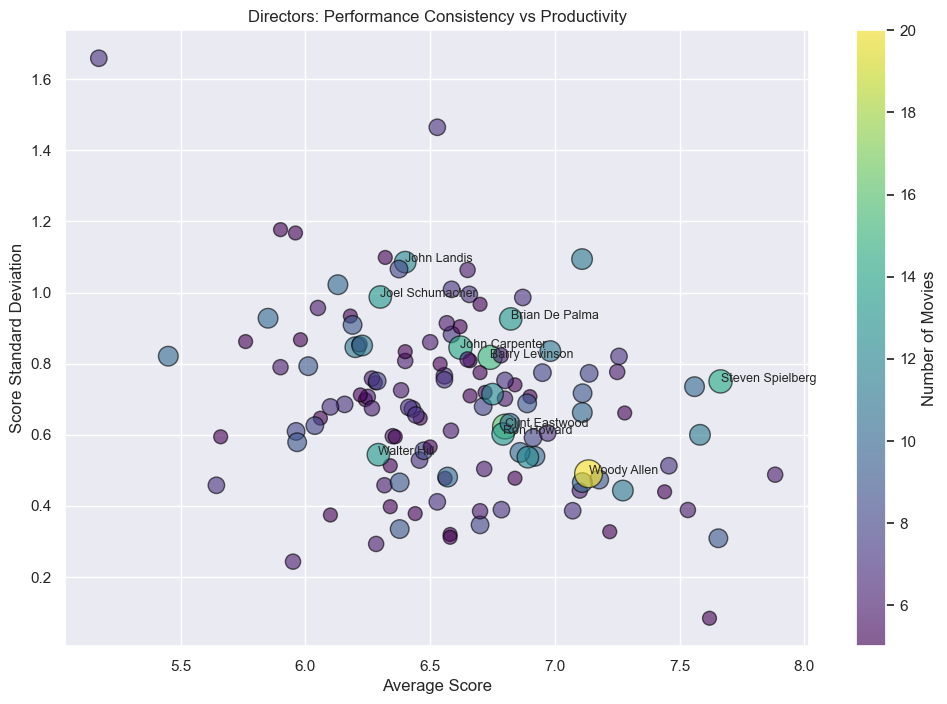

In [123]:
# 3. visualization
plt.figure(figsize=(12, 8))
scatter = plt.scatter(
    director_stats['AvgScore'],
    director_stats['StdDevScore'],
    s=director_stats['NumMovies'] * 20,   # bubble size proportional to number of movies
    alpha=0.6,
    c=director_stats['NumMovies'],        # color scale by productivity
    cmap='viridis',
    edgecolors='black'
)

# Annotate top directors by number of movies
for _, row in director_stats.nlargest(10, 'NumMovies').iterrows():
    plt.text(row['AvgScore'], row['StdDevScore'], row['director'], fontsize=9)

plt.xlabel('Average Score')
plt.ylabel('Score Standard Deviation')
plt.title('Directors: Performance Consistency vs Productivity')

# Add colorbar to show productivity scale
cbar = plt.colorbar(scatter)
cbar.set_label('Number of Movies')

plt.grid(True)
plt.show()

In [124]:
# 4
# companies with at least 20 movies
company_counts = roiTable['company'].value_counts()
valid_companies = company_counts[company_counts >= 20].index

# company filter
filtered_companies = roiTable[roiTable['company'].isin(valid_companies)]

# Group by company and calculate required metrics
company_stats = (
    filtered_companies.groupby('company')
    .agg(
        NumMovies=('name', 'count'),       # Number of movies produced
        AvgGross=('gross', 'mean'),        # Average gross revenue
        AvgROI=('ROI', 'mean'),            # Average ROI
        AvgScore=('score', 'mean')         # Average score
    )
    .reset_index()
)

print(company_stats)


                       company  NumMovies      AvgGross    AvgROI  AvgScore
0    Castle Rock Entertainment         34  4.618047e+07  0.484668  6.582353
1            Columbia Pictures        145  5.897084e+07  3.177172  6.353103
2           Hollywood Pictures         34  7.502884e+07  1.583892  6.385294
3    Metro-Goldwyn-Mayer (MGM)         51  3.512960e+07  0.717544  6.100000
4                      Miramax         35  4.987588e+07  3.018350  6.648571
5   Morgan Creek Entertainment         24  3.251726e+07  0.492084  6.158333
6              New Line Cinema         66  6.722363e+07  2.428622  6.183333
7               Orion Pictures         44  2.544461e+07  1.301031  6.343182
8           Paramount Pictures        151  9.498667e+07  3.598430  6.375497
9          Touchstone Pictures         66  9.715339e+07  2.370736  6.542424
10            TriStar Pictures         61  6.055418e+07  1.564319  6.329508
11       Twentieth Century Fox         95  1.226684e+08  2.294396  6.356842
12          

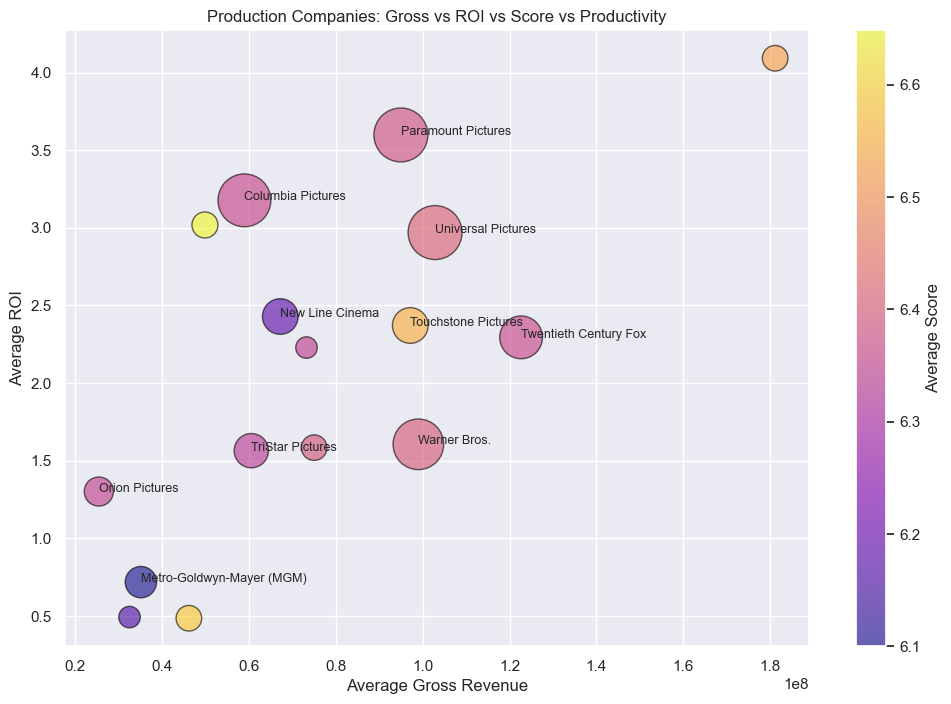

In [86]:
#5. Create a visualization that displays all four metrics simultaneously.
plt.figure(figsize=(12, 8))

# Bubble plot: AvgGross vs AvgROI, size = NumMovies, color = AvgScore
scatter = plt.scatter(
    company_stats['AvgGross'],           # X‑axis → Average Gross Revenue
    company_stats['AvgROI'],             # Y‑axis → Average ROI
    s=company_stats['NumMovies'] * 10,   # Bubble size → Number of Movies Produced
    alpha=0.6,
    c=company_stats['AvgScore'],         # Bubble color → Average Score
    cmap='plasma',
    edgecolors='black'
)

# Annotate top 10 companies by number of movies
for _, row in company_stats.nlargest(10, 'NumMovies').iterrows():
    plt.text(row['AvgGross'], row['AvgROI'], row['company'], fontsize=9)

plt.xlabel('Average Gross Revenue')
plt.ylabel('Average ROI')
plt.title('Production Companies: Gross vs ROI vs Score vs Productivity')

# Add colorbar to show AvgScore scale
cbar = plt.colorbar(scatter)
cbar.set_label('Average Score')

plt.grid(True)
plt.show()


In [ ]:
answering the questions
6. Using your visualizations:
Identify three directors who are consistently successful.
• this three sit in the bottom right quadrant, which represents reliable, high quality output.
    •	Steven Spielberg → High average score (~7.8) and low variability.
    •	Woody Allen → High productivity (large yellow bubble) and consistent scores.
    •	Clint Eastwood → Solid average score (~7.0) with relatively low deviation.

Identify companies that prioritize quality over profitability.
    • These are studios with high AvgScore but low AvgROI .
           Company	              AvgScore	AvgROI
       - Castle Rock Entertainment	6.58	0.48
       - Morgan Creek Entertainment	6.16	0.49
       - Metro Goldwyn Mayer (MGM)	6.10	0.72

Identify companies that prioritize profitability over quality.
     • These have high AvgROI but lower AvgScore 
             Company	          AvgScore  AvgROI
           - Walt Disney Pictures	6.52	4.09
           - Paramount Pictures	    6.38	3.60
           - Columbia Pictures	    6.35	3.18


In [ ]:
Exercise 3

In [91]:
# 1. Create decade groups from release year
roiTable['decade'] = (roiTable['year'] // 10) * 10

# 2. Group by decade and genre, calculate stats
decade_genre_stats = (
    roiTable.groupby(['decade', 'genre'])
    .agg(
        NumMovies=('name', 'count'),       # number of movies
        AvgScore=('score', 'mean'),        # average score
        TotalGross=('gross', 'sum')        # total gross revenue
    )
    .reset_index()
    .sort_values(['decade', 'genre'])
)

print(decade_genre_stats)


    decade      genre  NumMovies  AvgScore    TotalGross
0     1980     Action        222  6.193243  1.083790e+10
1     1980  Adventure         72  6.156944  2.502041e+09
2     1980  Animation         19  7.126316  9.526155e+08
3     1980  Biography         32  7.131250  1.158281e+09
4     1980     Comedy        278  6.266187  8.896916e+09
5     1980      Crime         60  6.646667  1.049496e+09
6     1980      Drama        124  6.559677  3.676726e+09
7     1980     Family          1  7.800000  7.929106e+08
8     1980    Fantasy         14  6.185714  2.848261e+08
9     1980     Horror         60  6.025000  8.700108e+08
10    1980    Romance          1  7.000000  2.874436e+07
11    1980     Sci-Fi          3  6.266667  1.791165e+07
12    1980   Thriller          2  6.350000  1.288366e+07
13    1980    Western          1  6.400000  1.736123e+06
14    1990     Action        319  6.061129  3.200390e+10
15    1990  Adventure         75  6.085333  5.056631e+09
16    1990  Animation         4

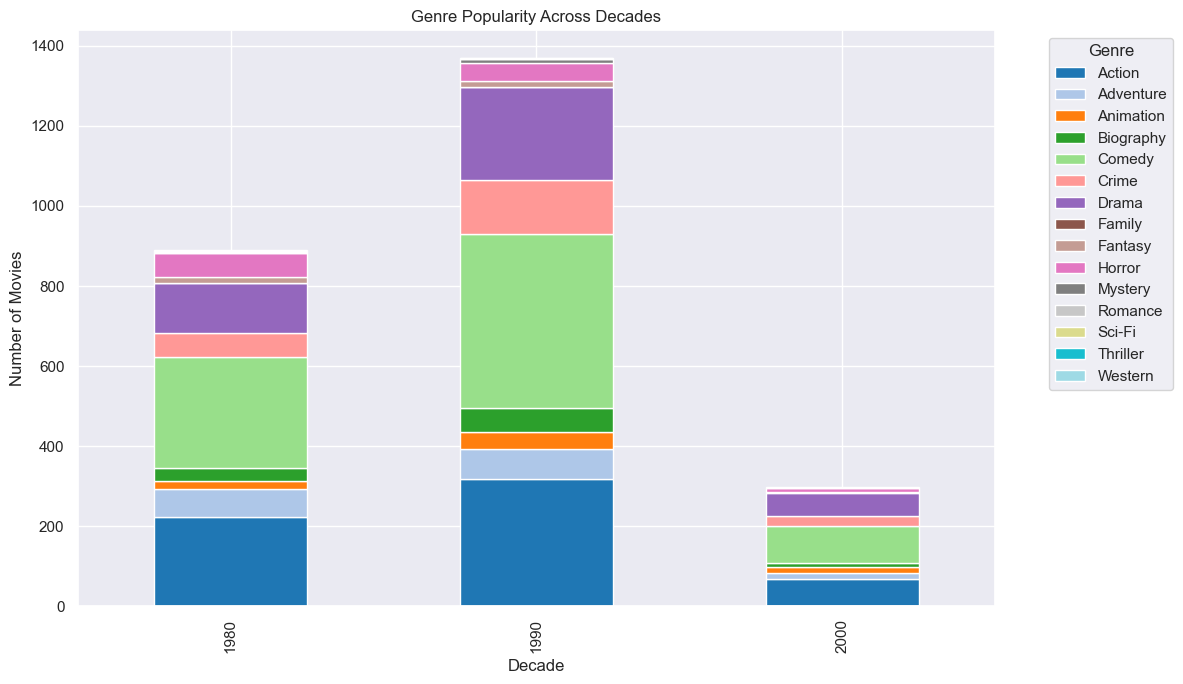

In [92]:
#3. Build a visualization that clearly shows how genre popularity evolved across decades.
# Use the decade_genre_stats DataFrame from step 2
pivot_data = decade_genre_stats.pivot(index='decade', columns='genre', values='NumMovies')

# Plot stacked bar chart
pivot_data.plot(kind='bar', stacked=True, figsize=(12, 7), colormap='tab20')

plt.title('Genre Popularity Across Decades')
plt.xlabel('Decade')
plt.ylabel('Number of Movies')
plt.legend(title='Genre', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


In [93]:
# 4. Filter countries with at least 30 movies
country_counts = roiTable['country'].value_counts()
valid_countries = country_counts[country_counts >= 30].index

filtered_countries = roiTable[roiTable['country'].isin(valid_countries)]

# 5. Group by country and calculate required metrics
country_stats = (
    filtered_countries.groupby('country')
    .agg(
        AvgScore=('score', 'mean'),       # average score
        AvgBudget=('budget', 'mean'),     # average budget
        AvgGross=('gross', 'mean'),       # average gross revenue
        AvgROI=('ROI', 'mean')            # average ROI
    )
    .reset_index()
)

print(country_stats)

          country  AvgScore     AvgBudget      AvgGross    AvgROI
0          Canada  5.868182  1.378130e+07  1.641894e+07  3.821059
1          France  6.653488  2.969767e+07  3.671473e+07  0.396613
2  United Kingdom  6.520488  1.978217e+07  3.672382e+07  1.412941
3   United States  6.322053  2.486950e+07  6.183119e+07  4.031610


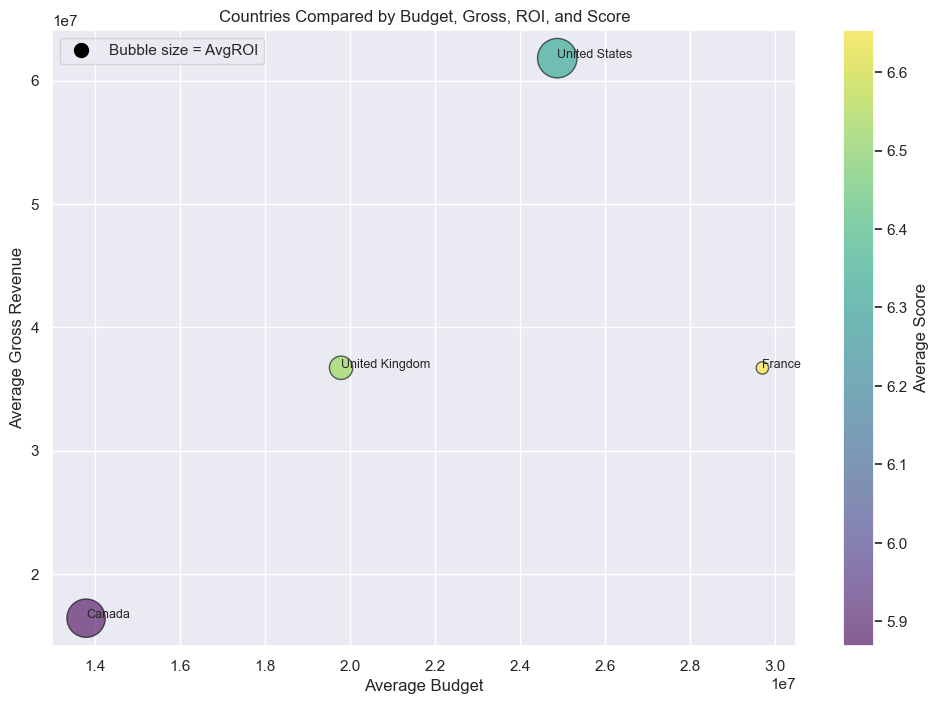

In [95]:
#6. visualization
plt.figure(figsize=(12, 8))

# Bubble plot: AvgBudget vs AvgGross
scatter = plt.scatter(
    country_stats['AvgBudget'],          # X-axis → Average Budget
    country_stats['AvgGross'],           # Y-axis → Average Gross Revenue
    s=country_stats['AvgROI'] * 200,     # Bubble size → Average ROI (scaled for visibility)
    alpha=0.6,
    c=country_stats['AvgScore'],         # Bubble color → Average Score
    cmap='viridis',
    edgecolors='black'
)

# Annotate top 5 countries by number of movies
for _, row in country_stats.nlargest(5, 'AvgGross').iterrows():
    plt.text(row['AvgBudget'], row['AvgGross'], row['country'], fontsize=9)

plt.xlabel('Average Budget')
plt.ylabel('Average Gross Revenue')
plt.title('Countries Compared by Budget, Gross, ROI, and Score')

# Add colorbar for AvgScore
cbar = plt.colorbar(scatter)
cbar.set_label('Average Score')

# Add legend for bubble size (ROI)
import matplotlib.lines as mlines
legend1 = mlines.Line2D([], [], color='black', marker='o', linestyle='None',
                        markersize=10, label='Bubble size = AvgROI')
plt.legend(handles=[legend1], loc='upper left')

plt.grid(True)
plt.show()


In [96]:
# 7. Define Hidden Gem condition
median_votes = roiTable['votes'].median()
hidden_gems = roiTable[(roiTable['score'] >= 8) & (roiTable['votes'] < median_votes)]

# 8. Calculate number of hidden gems by genre and country
hidden_gems_stats = (
    hidden_gems.groupby(['genre', 'country'])
    .agg(NumHiddenGems=('name', 'count'))
    .reset_index()
    .sort_values(['genre', 'NumHiddenGems'], ascending=[True, False])
)

print(hidden_gems_stats)


       genre                country  NumHiddenGems
0  Biography          United States              1
1      Drama  Republic of Macedonia              1


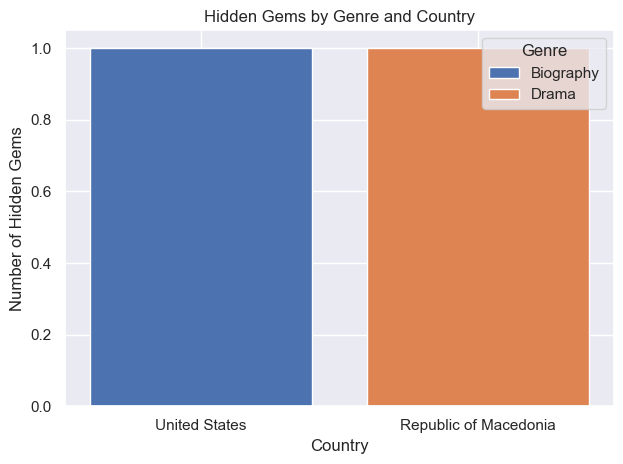

In [104]:
#9. Create a visualization that highlights where hidden gems are most commonly found.
for genre in hidden_gems_stats['genre'].unique():
    subset = hidden_gems_stats[hidden_gems_stats['genre'] == genre]
    plt.bar(
        subset['country'],
        subset['NumHiddenGems'],
        label=genre
    )

plt.title('Hidden Gems by Genre and Country')
plt.xlabel('Country')
plt.ylabel('Number of Hidden Gems')
plt.legend(title='Genre')
plt.tight_layout()
plt.show()


In [ ]:
answering the questions
10. Based on your analysis, answer the following questions:
Which genres gained popularity over time?
  - Action, Comedy, Drama, and Biography gained the most traction across decades.
Which countries produce the highest-quality movies relative to budget?
  -France has highest quality relative to budget (quality‑focused). United Kingdom has balanced quality and profitability. United States is profit‑focused.
Which genre and country combinations appear to be the most underrated by audiences?
  - Biography - US and  Drama - Macedonia